In [21]:
#!unrar x 001.rar
!unrar x 007.rar
!unrar x test_007.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from 007.rar

Creating    007                                                       OK
Extracting  007/00000.png                                                  1%  OK 
Extracting  007/00001.png                                                  3%  OK 
Extracting  007/00002.png                                                  5%  OK 
Extracting  007/00003.png                                                  6%  OK 
Extracting  007/00004.png                                                  7%  OK 
Extracting  007/00005.png                                                  9%  OK 
Extracting  007/00006.png                                                 10%  OK 
Extracting  007/00007.png                                                 11%  OK 
Extracting  007/00008.png                                                 13%  OK

In [10]:
!rm -rf /content/010
!rm -rf /content/test_010

In [ ]:
import cv2
import os
import numpy as np
import math
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

def analyze_with_ground_truth_rgb(
    folder_test,
    folder_gt,
    center_x,
    center_y,
    rect_width,
    rect_height,
    data_range=255.0
):
    """
    Per ogni immagine nella cartella 'folder_test' carica la corrispondente
    immagine in 'folder_gt' (stesso nome di file). Calcola SSIM e PSNR
    'dentro' il rettangolo e 'fuori' il rettangolo, confrontando test vs ground truth
    su immagini RGB.
    Restituisce le medie di SSIM e PSNR su tutti i frame, separatamente per dentro e fuori.
    """

    # 1) Ottieni la lista di immagini in modalità ordinata
    test_files = sorted([
        f for f in os.listdir(folder_test)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])
    gt_files = sorted([
        f for f in os.listdir(folder_gt)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    # 2) Intersezione dei nomi: processa solo i file presenti in entrambe le cartelle
    common_files = sorted([f for f in test_files if f in gt_files])
    if len(common_files) == 0:
        raise RuntimeError("Nessun file corrispondente trovato tra cartella di test e ground truth.")

    # 3) Carica un esempio per ottenere dimensioni (H, W)
    sample_path = os.path.join(folder_test, common_files[0])
    sample_img = cv2.imread(sample_path)
    if sample_img is None:
        raise RuntimeError(f"Impossibile caricare l'immagine {common_files[0]}.")
    H, W = sample_img.shape[:2]

    # 4) Calcola i vertici del rettangolo, con clipping ai bordi
    x1 = max(0, center_x - rect_width // 2)
    y1 = max(0, center_y - rect_height // 2)
    x2 = min(W, center_x + rect_width // 2)
    y2 = min(H, center_y + rect_height // 2)

    # 5) Maschera booleana per l'area esterna
    mask_outside = np.ones((H, W), dtype=bool)
    mask_outside[y1:y2, x1:x2] = False

    # 6) Liste per accumulare SSIM e PSNR
    ssim_inside_list = []
    psnr_inside_list = []
    ssim_outside_list = []
    psnr_outside_list = []

    # 7) Loop su ogni file comune
    for fname in common_files:
        path_test = os.path.join(folder_test, fname)
        path_gt   = os.path.join(folder_gt,   fname)

        img_test = cv2.imread(path_test)
        img_gt   = cv2.imread(path_gt)
        if img_test is None or img_gt is None:
            print(f"Attenzione: impossibile caricare {fname}, salto questo frame.")
            continue

        # Converti BGR->RGB
        img_test_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
        img_gt_rgb   = cv2.cvtColor(img_gt,   cv2.COLOR_BGR2RGB)

        # 7a) Dentro la regione: estrai la patch RGB
        patch_test = img_test_rgb[y1:y2, x1:x2, :]
        patch_gt   = img_gt_rgb[y1:y2, x1:x2, :]
        if patch_test.size == 0 or patch_gt.size == 0:
            print(f"Attenzione: patch vuota per {fname}, salto questa patch.")
            continue

        # Calcola PSNR_Region su patch RGB
        try:
            psnr_in = psnr_metric(patch_gt, patch_test, data_range=data_range)
            # Se inf, mettiamo un valore alto fisso 
            if math.isinf(psnr_in):
                psnr_in = 100.0
        except Exception:
            psnr_in = None

        # Calcola SSIM_Region su patch RGB con win_size adattivo
        try:
            h_reg, w_reg = patch_gt.shape[:2]
            
            base_win = min(11, min(H, W))
            if base_win % 2 == 0:
                base_win -= 1
            # Calcola la dimensione della finestra in base alla patch
            # Se la patch è più piccola della finestra base, usa la dimensione minima
            win_reg = min(base_win, min(h_reg, w_reg))
            if win_reg % 2 == 0:
                win_reg = max(1, win_reg - 1)
            if win_reg >= 3:
                ssim_in = ssim_metric(
                    patch_gt, patch_test,
                    data_range=data_range,
                    channel_axis=-1,
                    win_size=win_reg
                )
            else:
                # Se troppo piccolo, ricadi su win_size default senza channel_axis
                ssim_in = ssim_metric(
                    cv2.cvtColor(patch_gt, cv2.COLOR_RGB2GRAY),
                    cv2.cvtColor(patch_test, cv2.COLOR_RGB2GRAY),
                    data_range=data_range
                )
        except Exception:
            ssim_in = None

        if ssim_in is not None:
            ssim_inside_list.append(ssim_in)
        if psnr_in is not None:
            psnr_inside_list.append(psnr_in)

        # 7b) Fuori dalla regione: calcolo full SSIM map e media su mask_outside
       
        try:
            base_win = min(11, min(H, W))
            if base_win % 2 == 0:
                base_win -= 1
            _, ssim_map = ssim_metric(
                img_gt_rgb, img_test_rgb,
                data_range=data_range,
                channel_axis=-1,
                win_size=base_win,
                full=True
            )
            
            if ssim_map.ndim == 3:
                ssim_map_mean = np.mean(ssim_map, axis=-1)
            else:
                ssim_map_mean = ssim_map
            outside_vals = ssim_map_mean[mask_outside]
            if outside_vals.size > 0:
                ssim_out = np.mean(outside_vals)
            else:
                ssim_out = None
        except Exception:
            ssim_out = None

        # Calcola PSNR_Outside su RGB: MSE manuale sui pixel esterni
        try:
            # Differenza quadratica su tutti i canali
            diff_map = (img_gt_rgb.astype(np.float64) - img_test_rgb.astype(np.float64)) ** 2
            outside_sq = diff_map[mask_outside]
            if outside_sq.size > 0:
                mse_out = np.mean(outside_sq)
                if mse_out <= 1e-10:
                    psnr_out = 100.0
                else:
                    psnr_out = 10.0 * math.log10((data_range ** 2) / mse_out)
                    if math.isinf(psnr_out):
                        psnr_out = 100.0
            else:
                psnr_out = None
        except Exception:
            psnr_out = None

        if ssim_out is not None:
            ssim_outside_list.append(ssim_out)
        if psnr_out is not None:
            psnr_outside_list.append(psnr_out)

    # 8) Calcola medie finali
    mean_ssim_inside = np.mean(ssim_inside_list) if ssim_inside_list else float("nan")
    mean_psnr_inside = np.mean(psnr_inside_list) if psnr_inside_list else float("nan")
    mean_ssim_outside = np.mean(ssim_outside_list) if ssim_outside_list else float("nan")
    mean_psnr_outside = np.mean(psnr_outside_list) if psnr_outside_list else float("nan")

    # 9) Stampa dei risultati medi
    print("=== RISULTATI MEDI (Test VS Ground Truth, RGB) ===")
    print(f"Numero totale di frame confrontati: {len(ssim_inside_list)}\n")

    print("Dentro la regione rettangolare:")
    if not math.isnan(mean_ssim_inside):
        print(f"  • SSIM medio = {mean_ssim_inside:.4f}")
    else:
        print("  • SSIM medio = N/A")
    if not math.isnan(mean_psnr_inside):
        print(f"  • PSNR medio = {mean_psnr_inside:.2f} dB")
    else:
        print("  • PSNR medio = N/A")

    print("\nFuori dalla regione rettangolare:")
    if not math.isnan(mean_ssim_outside):
        print(f"  • SSIM medio = {mean_ssim_outside:.4f}")
    else:
        print("  • SSIM medio = N/A")
    if not math.isnan(mean_psnr_outside):
        print(f"  • PSNR medio = {mean_psnr_outside:.2f} dB")
    else:
        print("  • PSNR medio = N/A")


# =========================
# UTILIZZO
# =========================

folder_test  = "007"       # cartella con le immagini di test
folder_gt    = "test_007"  # cartella con le immagini di ground truth
center_x     = 300         # coordinata x del centro del rettangolo
center_y     = 200         # coordinata y del centro del rettangolo
rect_width   = 300         # larghezza del rettangolo
rect_height  = 300         # altezza del rettangolo

analyze_with_ground_truth_rgb(
    folder_test, folder_gt,
    center_x, center_y,
    rect_width, rect_height
)


=== RISULTATI MEDI (Test VS Ground Truth, RGB) ===
Numero totale di frame confrontati: 59

Dentro la regione rettangolare:
  • SSIM medio = 0.8841
  • PSNR medio = 17.63 dB

Fuori dalla regione rettangolare:
  • SSIM medio = 0.8735
  • PSNR medio = 15.28 dB


=== RISULTATI MEDI (Test VS Ground Truth, RGB) ===
Numero totale di frame confrontati: 67

Dentro la regione rettangolare:
  • SSIM medio = 0.8318
  • PSNR medio = 16.09 dB

Fuori dalla regione rettangolare:
  • SSIM medio = 0.8631
  • PSNR medio = 16.52 dB

Mostro ora le immagini di test con il rettangolo rosso:


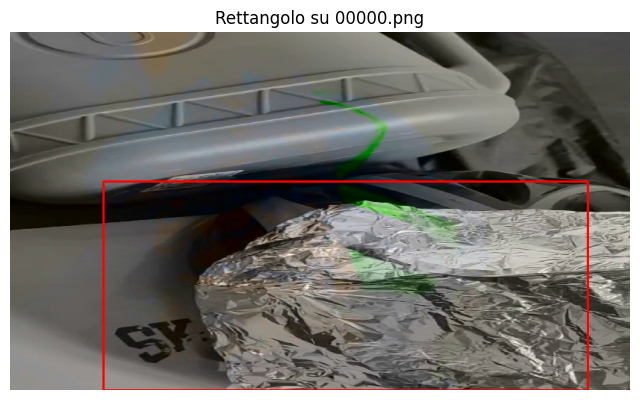

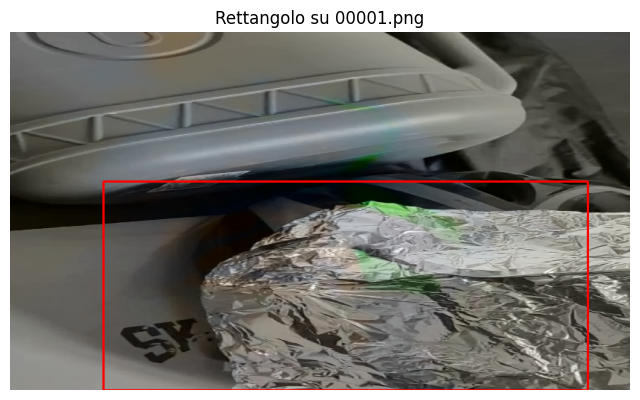

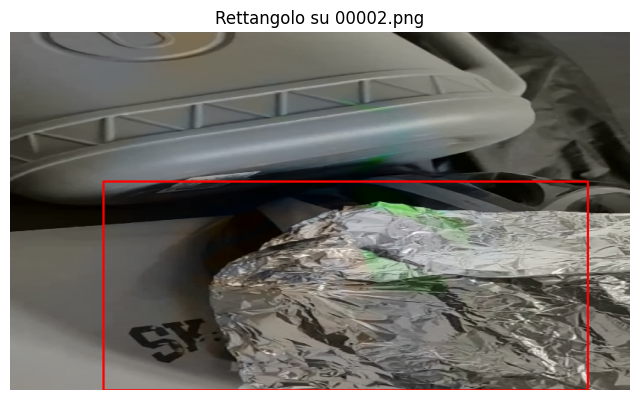

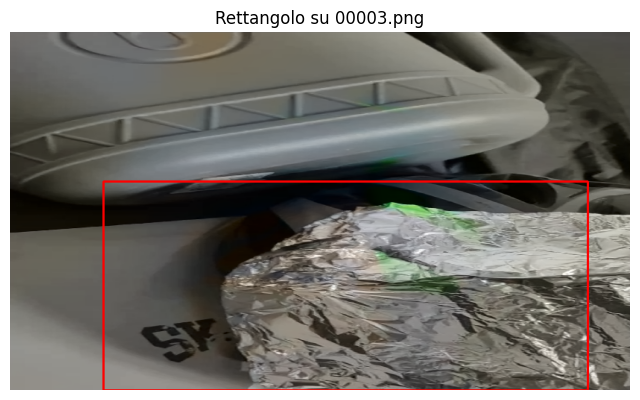

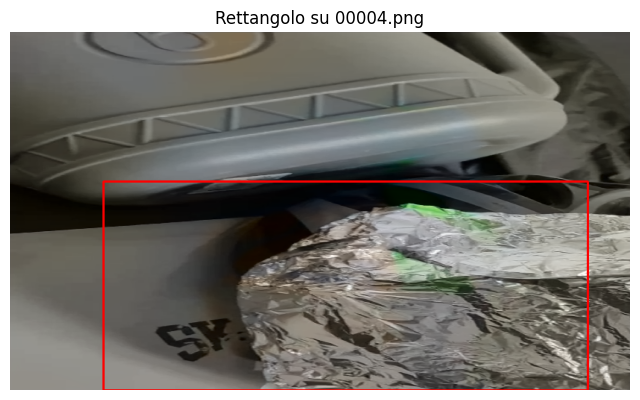

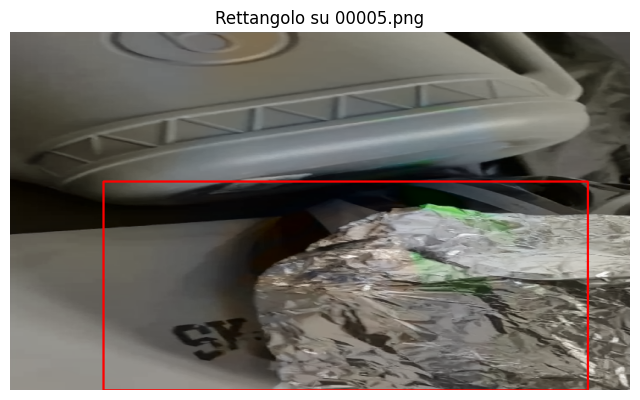

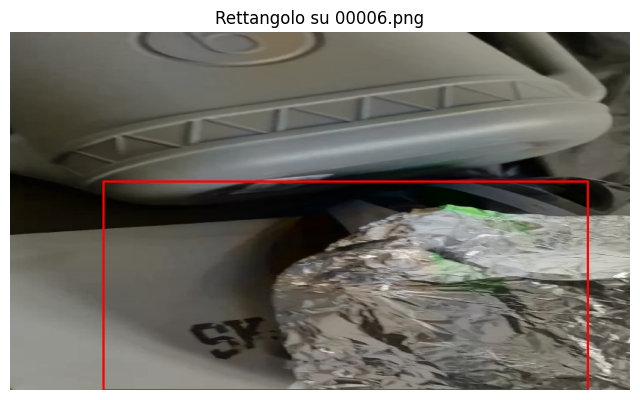

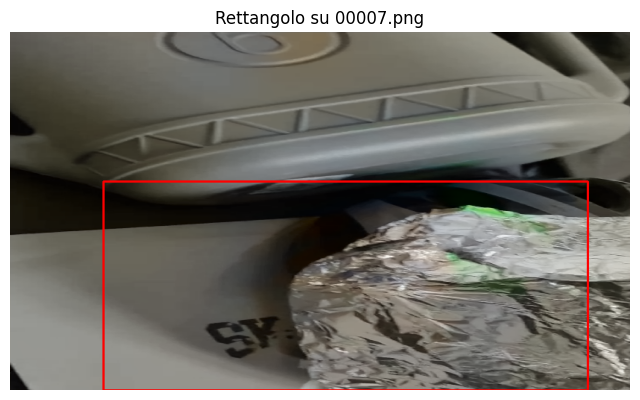

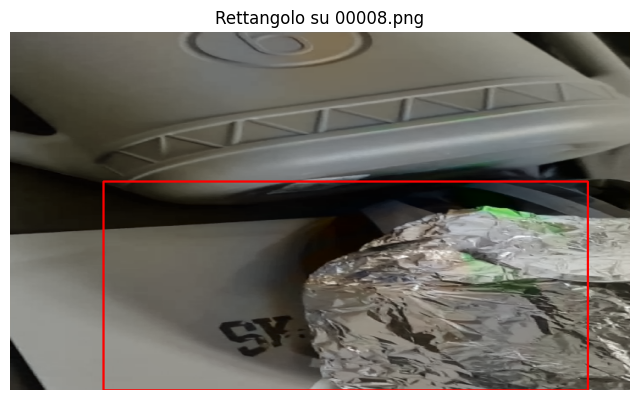

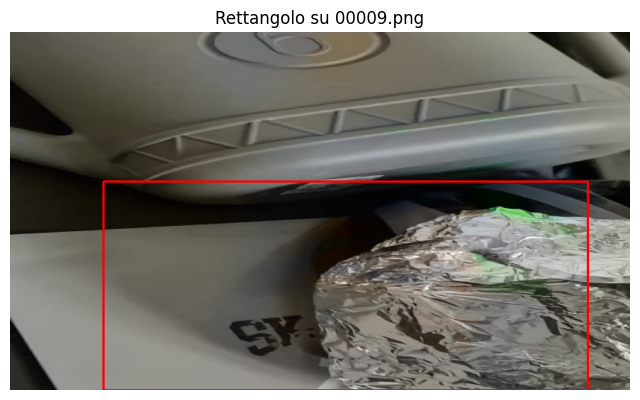

KeyboardInterrupt: 

In [ ]:
import cv2
import os
import numpy as np
import math
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
import matplotlib.pyplot as plt

def analyze_with_ground_truth_and_show(
    folder_test,
    folder_gt,
    center_x,
    center_y,
    rect_width,
    rect_height,
    data_range=255.0
):
    """
    - Confronta ciascuna immagine di 'folder_test' con la corrispondente in 'folder_gt'
      (stesso nome), calcolando SSIM e PSNR dentro e fuori la regione rettangolare (RGB).
    - Stampa i valori medi di SSIM/PSNR (Region e Outside) su tutti i frame.
    - Poi disegna un rettangolo rosso (spessore 2 px) su ogni immagine di test,
      mostra l’immagine con matplotlib e passa all’immagine successiva.
    """

    # 1) Prepara la lista ordinata di file 
    test_files = sorted([f for f in os.listdir(folder_test)
                         if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    gt_files   = sorted([f for f in os.listdir(folder_gt)
                         if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    common_files = sorted([f for f in test_files if f in gt_files])
    if len(common_files) == 0:
        raise RuntimeError("Nessun file corrispondente trovato tra cartella di test e ground truth.")

    # 2) Carica un esempio 
    sample_path = os.path.join(folder_test, common_files[0])
    sample_img = cv2.imread(sample_path)
    if sample_img is None:
        raise RuntimeError(f"Impossibile caricare l'immagine {common_files[0]}.")
    H, W = sample_img.shape[:2]

    # 3) Definisci il rettangolo (clippato ai bordi)
    x1 = max(0, center_x - rect_width // 2)
    y1 = max(0, center_y - rect_height // 2)
    x2 = min(W, center_x + rect_width // 2)
    y2 = min(H, center_y + rect_height // 2)

    # 4) Maschera booleana per l'area esterna
    mask_outside = np.ones((H, W), dtype=bool)
    mask_outside[y1:y2, x1:x2] = False

    # 5) Accumulatore per metriche
    ssim_inside_list = []
    psnr_inside_list = []
    ssim_outside_list = []
    psnr_outside_list = []

    # 6) Loop calcolo metriche
    for fname in common_files:
        path_test = os.path.join(folder_test, fname)
        path_gt   = os.path.join(folder_gt,   fname)

        img_test = cv2.imread(path_test)
        img_gt   = cv2.imread(path_gt)
        if img_test is None or img_gt is None:
            print(f"Attenzione: impossibile caricare {fname}, salto.")
            continue

        # BGR -> RGB
        img_test_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
        img_gt_rgb   = cv2.cvtColor(img_gt,   cv2.COLOR_BGR2RGB)

        # 6a) Dentro la regione: estrai patch RGB
        patch_test = img_test_rgb[y1:y2, x1:x2, :]
        patch_gt   = img_gt_rgb[y1:y2, x1:x2, :]
        if patch_test.size == 0 or patch_gt.size == 0:
            print(f"Attenzione: patch vuota per {fname}, salto patch.")
            continue

        # PSNR Region (RGB)
        try:
            psnr_in = psnr_metric(patch_gt, patch_test, data_range=data_range)
            if math.isinf(psnr_in):
                psnr_in = 100.0
        except Exception:
            psnr_in = None

        # SSIM Region (RGB) con win_size adattivo
        try:
            h_reg, w_reg = patch_gt.shape[:2]
            base_win = min(11, min(H, W))
            if base_win % 2 == 0:
                base_win -= 1
            win_reg = min(base_win, min(h_reg, w_reg))
            if win_reg % 2 == 0:
                win_reg = max(1, win_reg - 1)
            if win_reg >= 3:
                ssim_in = ssim_metric(
                    patch_gt, patch_test,
                    data_range=data_range,
                    channel_axis=-1,
                    win_size=win_reg
                )
            else:
                # Se troppo piccolo, fallback su grayscale
                gray_patch_gt = cv2.cvtColor(patch_gt, cv2.COLOR_RGB2GRAY)
                gray_patch_test = cv2.cvtColor(patch_test, cv2.COLOR_RGB2GRAY)
                ssim_in = ssim_metric(
                    gray_patch_gt,
                    gray_patch_test,
                    data_range=data_range
                )
        except Exception:
            ssim_in = None

        if ssim_in is not None:
            ssim_inside_list.append(ssim_in)
        if psnr_in is not None:
            psnr_inside_list.append(psnr_in)

        # 6b) Fuori la regione:
        #    SSIM: mappa full-frame, media sui pixel esterni
        try:
            base_win = min(11, min(H, W))
            if base_win % 2 == 0:
                base_win -= 1
            _, ssim_map = ssim_metric(
                img_gt_rgb, img_test_rgb,
                data_range=data_range,
                channel_axis=-1,
                win_size=base_win,
                full=True
            )
            if ssim_map.ndim == 3:
                ssim_map_mean = np.mean(ssim_map, axis=-1)
            else:
                ssim_map_mean = ssim_map
            outside_vals = ssim_map_mean[mask_outside]
            ssim_out = np.mean(outside_vals) if outside_vals.size > 0 else None
        except Exception:
            ssim_out = None

        #    PSNR Outside: MSE manuale su tutti i canali
        try:
            diff_map = (img_gt_rgb.astype(np.float64) - img_test_rgb.astype(np.float64)) ** 2
            outside_sq = diff_map[mask_outside]
            if outside_sq.size > 0:
                mse_out = np.mean(outside_sq)
                if mse_out <= 1e-10:
                    psnr_out = 100.0
                else:
                    psnr_out = 10.0 * math.log10((data_range ** 2) / mse_out)
                    if math.isinf(psnr_out):
                        psnr_out = 100.0
            else:
                psnr_out = None
        except Exception:
            psnr_out = None

        if ssim_out is not None:
            ssim_outside_list.append(ssim_out)
        if psnr_out is not None:
            psnr_outside_list.append(psnr_out)

    # 7) Calcola le medie finali
    mean_ssim_inside  = np.mean(ssim_inside_list)  if ssim_inside_list  else float("nan")
    mean_psnr_inside  = np.mean(psnr_inside_list)  if psnr_inside_list  else float("nan")
    mean_ssim_outside = np.mean(ssim_outside_list) if ssim_outside_list else float("nan")
    mean_psnr_outside = np.mean(psnr_outside_list) if psnr_outside_list else float("nan")

    # 8) Stampa risultati medi
    print("=== RISULTATI MEDI (Test VS Ground Truth, RGB) ===")
    print(f"Numero totale di frame confrontati: {len(ssim_inside_list)}\n")

    print("Dentro la regione rettangolare:")
    if not math.isnan(mean_ssim_inside):
        print(f"  • SSIM medio = {mean_ssim_inside:.4f}")
    else:
        print("  • SSIM medio = N/A")
    if not math.isnan(mean_psnr_inside):
        print(f"  • PSNR medio = {mean_psnr_inside:.2f} dB")
    else:
        print("  • PSNR medio = N/A")

    print("\nFuori dalla regione rettangolare:")
    if not math.isnan(mean_ssim_outside):
        print(f"  • SSIM medio = {mean_ssim_outside:.4f}")
    else:
        print("  • SSIM medio = N/A")
    if not math.isnan(mean_psnr_outside):
        print(f"  • PSNR medio = {mean_psnr_outside:.2f} dB")
    else:
        print("  • PSNR medio = N/A")

    # 9) Dopo aver stampato le metriche, mostra le immagini di test con rettangolo rosso
    print("\nMostro ora le immagini di test con il rettangolo rosso:")
    for fname in common_files:
        path_test = os.path.join(folder_test, fname)
        img_test = cv2.imread(path_test)
        if img_test is None:
            continue

        # Disegna il rettangolo rosso (BGR = (0, 0, 255), spessore = 2)
        top_left     = (x1, y1)
        bottom_right = (x2, y2)
        cv2.rectangle(img_test, top_left, bottom_right, (0, 0, 255), 2)

        # Converti BGR -> RGB per matplotlib
        img_to_show = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8, 6))
        plt.imshow(img_to_show)
        plt.title(f"Rettangolo su {fname}")
        plt.axis("off")
        plt.show()


# =========================
# UTILIZZO
# =========================

folder_test  = "007"       # cartella con le immagini di test
folder_gt    = "test_007"  # cartella con le immagini di ground truth
center_x     = 450         # coordinata x del centro del rettangolo
center_y     = 350         # coordinata y del centro del rettangolo
rect_width   = 650         # larghezza del rettangolo
rect_height  = 300         # altezza del rettangolo

analyze_with_ground_truth_and_show(
    folder_test, folder_gt,
    center_x, center_y,
    rect_width, rect_height
)
